In [13]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

(<Axes: >, <matplotlib.image.AxesImage at 0x220ed5765d0>)

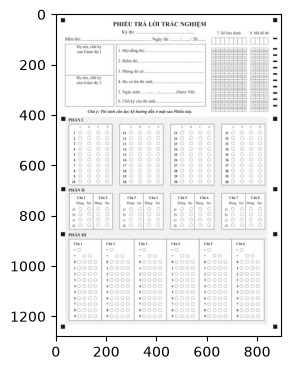

In [14]:
img_root = cv.imread('./data/sample1.jpg', cv.IMREAD_COLOR_BGR)
img = cv.cvtColor(img_root,cv.COLOR_BGR2GRAY)
plt.subplot(121),plt.imshow(img,cmap = 'gray')

(<Axes: >, <matplotlib.image.AxesImage at 0x220ed60c050>)

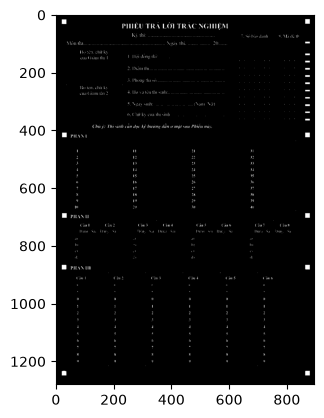

In [15]:
_, thresh = cv.threshold(img, 100, 255, cv.THRESH_BINARY_INV)
plt.subplot(111),plt.imshow(thresh,cmap = 'gray')


In [ ]:
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

In [17]:
square_candidates = []
for c in contours:
    x,y,w,h = cv.boundingRect(c)
    area = cv.contourArea(c)

    if area < 100 or area > 5000:
        continue

    aspect_ratio = float(w) / h
    if not (0.85 <= aspect_ratio <= 1.15):
        continue

    extent = area / float(w * h)
    if extent < 0.80:
        continue

    M = cv.moments(c)
    if M['m00'] != 0:
        cx = M['m10'] /M['m00']
        cy = M['m01'] /M['m00']
        square_candidates.append((cx,cy))

In [18]:
print(square_candidates)

[(871.515961395694, 1240.5159613956941), (28.44648318042813, 1240.7140672782873), (871.515961395694, 873.4840386043059), (28.468005952380953, 873.5), (871.5, 694.5), (29.5, 694.5), (871.5, 415.5), (29.5, 415.5), (28.524553571428573, 23.468005952380953), (871.5, 22.5)]


In [31]:
pts = np.array(square_candidates)

sum = pts[:,0] + pts[:,1]
tl = pts[np.argmin(sum)] #top left
br = pts[np.argmax(sum)] # btm right

different = pts[:,0] - pts[:,1]
tr = pts[np.argmax(different)]
bl = pts[np.argmin(different)]

src_corners = np.array([tl,tr,br,bl],dtype="float32")

In [32]:
src_corners

array([[  28.524553,   23.468006],
       [ 871.5     ,   22.5     ],
       [ 871.516   , 1240.516   ],
       [  28.446484, 1240.7141  ]], dtype=float32)

In [ ]:
# For example, placing markers at a 50px margin inside the canvas
dst_corners = np.array([
    [50, 50],             # Top-Left
    [1750, 50],           # Top-Right
    [1750, 2495],         # Bottom-Right
    [50, 2495]            # Bottom-Left
], dtype="float32")
M = cv.getPerspectiveTransform(src_corners, dst_corners)
warped_sheet = cv.warpPerspective(img, M, (1800, 2545))

cv.imshow("img",warped_sheet)

error: OpenCV(5.0.0) :-1: error: (-5:Bad argument) in function 'imshow'
> Overload resolution failed:
>  - imshow() missing required argument 'mat' (pos 2)
>  - imshow() missing required argument 'mat' (pos 2)
>  - imshow() missing required argument 'mat' (pos 2)
